# EDS 232 Machine Learning Competition (2026)
Sofia Sarak and Isabella Segarra 

## Background

This notebook contains a submission to the [EDS232: Machine Learning for Environmental Science](https://meds-eds-232.github.io/EDS-232-course-website/) Kaggle competition. In it, students compete to develop machine learning models that produce the lowest Mean Squared Error (MSE) for a specific dataset.

### Data

This competition uses data from the [California Cooperative Oceanic Fisheries Investigations (CalCOFI)](https://calcofi.org/) program, which is one of the longest-running oceanographic time series in the world. Data comes from seawater samples collected off of the California coast. Dissolved inorganic carbon (DIC) is the response variable and sea water temperature, alkalinity, depth, and salinity are the predictors. Not all predictor variables have to be used in the final models.

As part of the competiton, we were provided with a training and test set of these variables. Submission to the Kaggle competition requires a dataframe that contains only `id` and predicted `DIC` as columns.

## Setup

In [ ]:
# Import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

In [ ]:
# Import training and test sets
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

## Exploratory Data Analysis

In [ ]:
# View variables and their data types
train.dtypes

id                  int64
CTDTEMP_ITS90     float64
Salinity_PSS78    float64
Depth             float64
TA                float64
DIC               float64
dtype: object

In [ ]:
# View first few rows of df
train.head(3)

,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3


In [ ]:
# Explore the number of missing values for each column
train.isna().sum()

id                0
CTDTEMP_ITS90     0
Salinity_PSS78    0
Depth             0
TA                0
DIC               0
dtype: int64

#### Histograms of Predictors

What are the distribution of our four predictor variables?

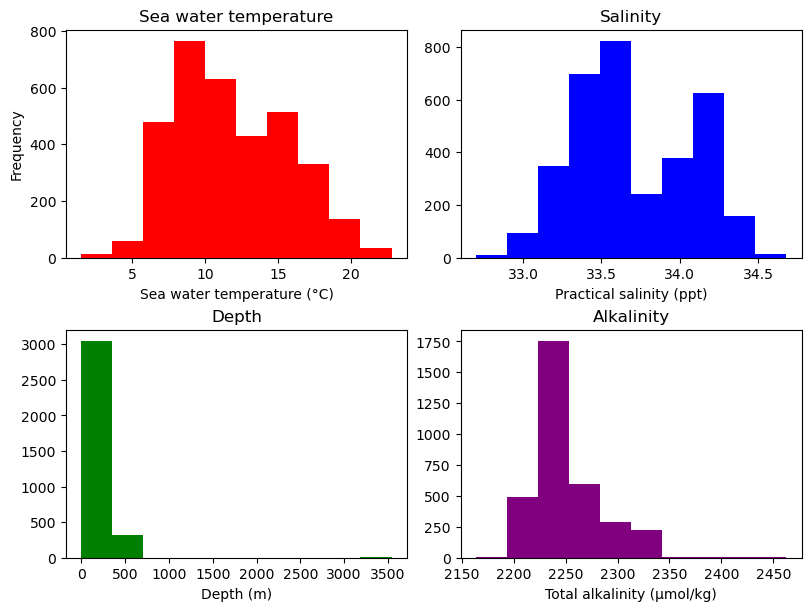

In [ ]:
# Initialize figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), layout = "constrained")

# Sea water temp plot
axes[0,0].hist(train['CTDTEMP_ITS90'], color = 'red')
axes[0,0].set_xlabel('Sea water temperature (°C)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Sea water temperature')

# Salinity plot
axes[0,1].hist(train['Salinity_PSS78'], color = 'blue')
axes[0,1].set_xlabel('Practical salinity (ppt)')
axes[0,0].set_ylabel('Frequency')
axes[0,1].set_title('Salinity')

# Depth plot
axes[1,0].hist(train['Depth'], color = 'green')
axes[1,0].set_xlabel('Depth (m)')
axes[0,0].set_ylabel('Frequency')
axes[1,0].set_title('Depth')

# Alkalinity plot
axes[1,1].hist(train['TA'], color = 'purple')
axes[1,1].set_xlabel('Total alkalinity (µmol/kg)')
axes[0,0].set_ylabel('Frequency')
axes[1,1].set_title('Alkalinity')

plt.show()

-  Sea water temperature has a relatively normal distribution
- Salinity can be described as bimodal
- Depth has a few very high outliers, skewing the distribution
- Alkalinity is has a right-skewed distribution.

#### Histogram of Response Variable

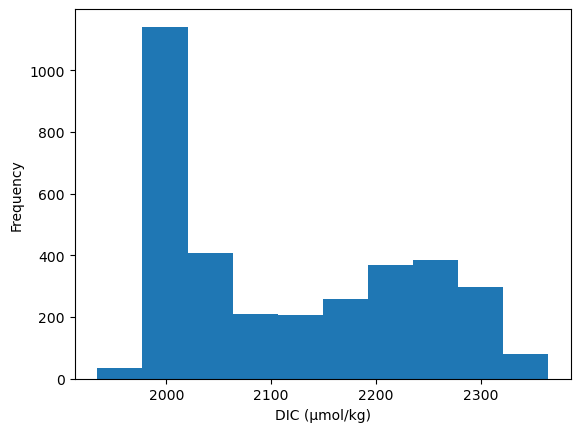

In [8]:
# Create histogram of `DIC`
train['DIC'].plot(kind = 'hist')
plt.xlabel('DIC (µmol/kg)')
plt.show()

The distribution if `DIC` appears bimodal.

#### Scatter plots comparing predictors to response (DIC)

What kind of relationship does each predictor variable have with DIC?

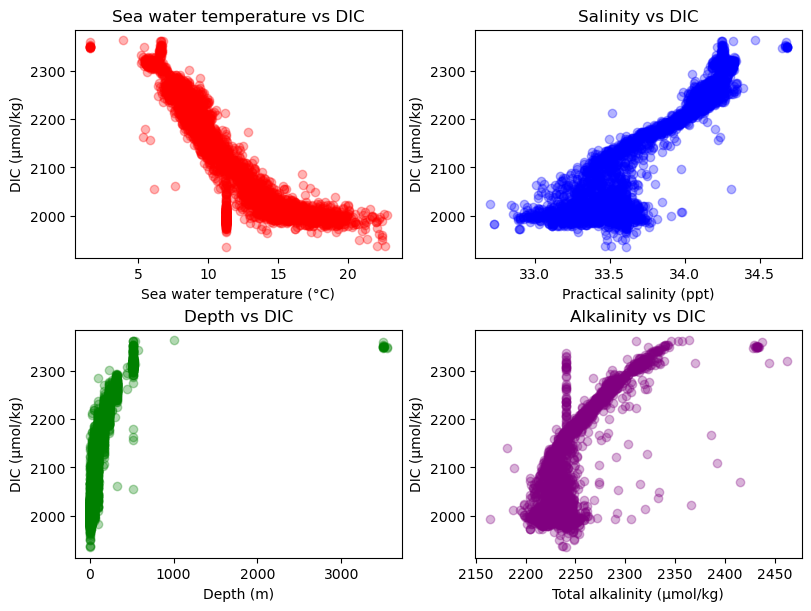

In [ ]:
# Initialize figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), layout = "constrained")

# Sea water temp plot
axes[0,0].scatter(train['CTDTEMP_ITS90'], train['DIC'], alpha = 0.3, color = 'red')
axes[0,0].set_xlabel('Sea water temperature (°C)')
axes[0,0].set_ylabel('DIC (µmol/kg)')
axes[0,0].set_title('Sea water temperature vs DIC')

# Salinity plot
axes[0,1].scatter(train['Salinity_PSS78'], train['DIC'], alpha = 0.3, color = 'blue')
axes[0,1].set_xlabel('Practical salinity (ppt)')
axes[0,1].set_ylabel('DIC (µmol/kg)')
axes[0,1].set_title('Salinity vs DIC')

# Depth plot
axes[1,0].scatter(train['Depth'], train['DIC'], alpha = 0.3, color = 'green')
axes[1,0].set_xlabel('Depth (m)')
axes[1,0].set_ylabel('DIC (µmol/kg)')
axes[1,0].set_title('Depth vs DIC')

# Alkalinity plot
axes[1,1].scatter(train['TA'], train['DIC'], alpha = 0.3, color = 'purple')
axes[1,1].set_xlabel('Total alkalinity (µmol/kg)')
axes[1,1].set_ylabel('DIC (µmol/kg)')
axes[1,1].set_title('Alkalinity vs DIC')

plt.show()

#### Correlation Matrix
How well correlated are these predictors?

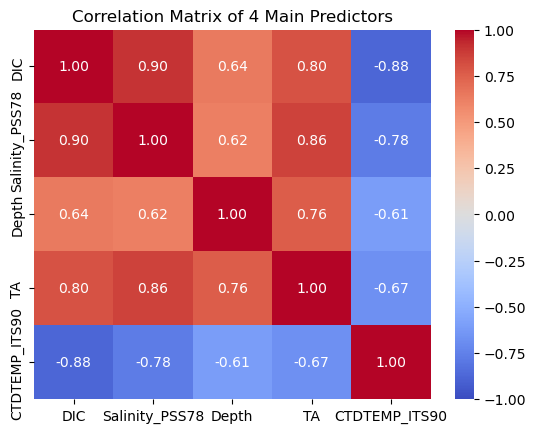

In [ ]:
# Calculate correlation between all variables
cols = ['DIC', 'Salinity_PSS78', 'Depth', 'TA', 'CTDTEMP_ITS90']  # adjust to your column names
corr = train[cols].corr()

# Plot
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of 4 Main Predictors")
plt.show()

- DIC shows strong positive correlations with salinity (0.90) and total alkalinity (0.80).
- DIS has a negative correlation with temperature (-0.88).
- Depth shows a medium positive correlation with TA
- Salnity and TA have a realtively strong relationship 

## Models

### Model Set-up

In [11]:
# Save features
features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]

# Create training predictors and response
X_train = train[features]
y_train = train['DIC']

# Create test sets
X_test = test[features]

# Scale data
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)


### Model 1: Ensemble - Random Forest

#### Hyperparameters and grid search

In [ ]:
# Create grid of parameters to tune on
param_grid = {
    'n_estimators': [50, 100],
    'max_features': ['sqrt', 'log2', 0.3, 0.4, 0.5],
    'max_depth': [10, 15, 20, 25, None]
}

# Initialize CV search for RF model with param_grid
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state= 42, n_jobs= -1),
            param_grid = param_grid,
            cv = 3,
            scoring =  'neg_mean_squared_error', # make sure this is the right scoring
            n_jobs = -1)

# Fit grid search on training data
rf_grid.fit(X_train_s, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20, 25, None],
                         'max_features': ['sqrt', 'log2', 0.3, 0.4, 0.5],
                         'n_estimators': [50, 100]},
             scoring='neg_mean_squared_error')

In [25]:
# Best model + params
best_model = rf_grid.best_estimator_
print("Best params:", rf_grid.best_params_)

# Evaluate on train
y_train_pred = best_model.predict(X_train) 
mse = mean_squared_error(y_train, y_train_pred)
print("Train MSE:", round(mse, 2))

# CV score -- the test
print("CV MSE:", round(-rf_grid.best_score_, 2)) # pulls out smallest CV MSE
rf_acc = round(-rf_grid.best_score_, 2)

Best params: {'max_depth': 20, 'max_features': 0.3, 'n_estimators': 50}
Train MSE: 20965.48
CV MSE: 492.79


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


#### Removing outliers from `Depth`

Based on the scatterplots we created in our exploration, the `Depth` variable has a handful of observations that appear to be extreme outliers. We explore how many observations this actually is, and then remove them from our `X_train` data to try to capture a more accurate relationship between `Depth` and `DIC`. This is done under the assumption that such outliers could potentially be a result of sampling/equipment error.

In [ ]:
# How many observations are outliers?
len(train[train['Depth'] > 2000])

13

In [ ]:
# Save observation where `Depth` is not an outlier
train_clean = train[train['Depth'] < 2000]
test_clean = test[test['Depth'] < 2000]

In [18]:
# Save train vars
X_train_clean = train_clean[features]
y_train_clean = train_clean['DIC']

# Save test vars
X_test_clean = test_clean[features]

# Scale
scaler = StandardScaler().fit(X_train_clean)
X_train_c_s = scaler.transform(X_train_clean)
X_test_c_s = scaler.transform(X_test_clean)

In [19]:
# Adjust grid 
param_grid_c = {
    'n_estimators': [50, 100],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.6],
    'max_depth': [20, 25, 30, 35, None]
}

# Initialize CV search for RF model with param_grid
rf_c_grid = GridSearchCV(
    RandomForestRegressor(random_state= 42, n_jobs= -1),
            param_grid = param_grid_c,
            cv = 3,
            scoring =  'neg_mean_squared_error', # make sure this is the right scoring
            n_jobs = -1)

# Fit grid search on new training data
rf_c_grid.fit(X_train_c_s, y_train_clean)

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [20, 25, 30, 35, None],
                         'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.6],
                         'n_estimators': [50, 100]},
             scoring='neg_mean_squared_error')

In [26]:
# Best model + params
best_model = rf_c_grid.best_estimator_
print("Best params:", rf_c_grid.best_params_)

# Evaluate on train
y_train_pred = best_model.predict(X_train) 
mse = mean_squared_error(y_train, y_train_pred)
print("Train MSE:", round(mse, 2))

# CV score -- the test
print("CV MSE:", round(-rf_c_grid.best_score_, 2)) # pulls out smallest CV MSE

rf_c_acc = round(-rf_c_grid.best_score_, 2)

Best params: {'max_depth': 30, 'max_features': 0.5, 'n_estimators': 50}
Train MSE: 15520.52
CV MSE: 494.7


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


Omitting outliers resulted in a lower-performing model.

### Model 2: Ensemble- XGBoost 


### Hyperparameters and grid search

In [27]:
# Define parameter grid 
    # Begin with only n_estimators, max_depth, and learning rate -- resulted in CV MSE 400+
param_grid = {
    'n_estimators': [500, 700, 800],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9], # fraction of observations used for randomly samples in each tree
    'colsample_bytree': [0.7, 0.8, 1.0], # ratio of columns when constructing each tree
    'gamma': [0, 0.1], # larger gamma = more conservative 
    'min_child_weight': [1, 3, 5] # used to control over-fitting
}

#  Search over hyperparameters 
grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
   
# Fit
grid_search.fit(X_train, y_train)

# Best model + params
best_model = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

# Evaluate on train
y_train_pred = best_model.predict(X_train) 
mse = mean_squared_error(y_train, y_train_pred)
print("Train MSE:", mse)

# CV score -- the test
print("CV MSE:", -grid_search.best_score_) # pulls out smallest CV MSE

xgb_acc = round(-grid_search.best_score_, 2)


python(10554) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10555) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10556) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10557) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10558) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10559) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10560) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10561) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.9}
Train MSE: 111.38269657941701
CV MSE: 307.5559531045341


Try again with scaled data.

In [28]:
grid_search.fit(X_train_s, y_train)
best_model = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

# Evaluate on train
y_train_pred = best_model.predict(X_train_s) 
mse = mean_squared_error(y_train, y_train_pred)
print("Train MSE:", mse)

# CV score -- the test
print("CV MSE:", -grid_search.best_score_)
xgb_s_acc = round(-grid_search.best_score_, 2)

python(10606) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10607) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10608) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10609) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10610) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10611) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10612) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10613) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.9}
Train MSE: 111.38269657941701
CV MSE: 307.5559531045341


## Submission

The XGBoost model performed the best, so we save its predicted values for Kaggle competition submission.

In [ ]:
# # Predict and submission 
# y_pred = best_model.predict(X_test) # predicted DIC
# submission = pd.DataFrame({'id': test['id'], 'DIC': y_pred})
# submission.to_csv('submission.csv', index=False)

## Summary 

#### Comparing models' CV MSE:

In [ ]:
# Create table
table = {
    # Model name
    'Model': ["Random Forest", "Random Forest (depth outliers removed)", "XGBoost", "XGBoost (scaled data)"],
    
    # MSE
    'CV MSE': [rf_acc, rf_c_acc, xgb_acc, xgb_s_acc]
}
# Convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

                                 Model  Accuracy
                         Random Forest    492.79
Random Forest (depth outliers removed)    494.70
                               XGBoost    307.56
                 XGBoost (scaled data)    307.56


The model that had the lowest CV MSE (and therefore performed the best) is the XGBoost model (scaling data made no difference in its performance). 

The XGBoost model use gradient boosting decision trees, which minimize bias and underfitting in the model. This contradicts the random forest model, which minimizes variance and overfitting by introducing randomness and controlling for tree length. The fact that XGBoost performs better here may suggest that our current data does not provide enough complexity or has too much noise, making it difficult for a model like random forest to parse out relationships. XGBoost tends to handle those qualities better.

Another reason both of our models may be performing rather poorly is due to potentially close-to-linear relationships between our predictor and response variables. Though visualizations show more exponential/curved patterns, it is possible that the frequency of certain data values can lead to a more linear relationship than what our models can account for.